In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, utils
from torchvision.transforms import ToTensor
from torchvision.io import decode_image
import matplotlib.pyplot as plt
import os



csv_path = "/kaggle/input/datasets/ginoleone117/filtered-coco/filtered_coco_metadata.csv"
images_path_train = "/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/train2017"

Helper cell just to get index of columns when needed #WARNING could change if csv file columns are removed, this csv file is downloaded from my local computer... Not from the output of the coco_preprocessing notebook

In [2]:
df = pd.read_csv(csv_path)
#print(df.head)
index = df.columns.get_loc("category_id")
#print(index)

In [3]:
image_augmentations = transforms.Compose([
    transforms.Resize((244, 244)),
    transforms.RandomHorizontalFlip(0.5),
    transforms.ColorJitter(0.4, 0.4, 0.2, 0.1)
])

Augmentation that gets applied to the image before it is passed into the CNN

In [4]:
class CocoVehicleDataset(Dataset):
    __slots__ = "csv_file", "root_directory", "transform"
    
    def __init__(self, csv_file, root_directory, transform = None):
        """
        Initializes csv file
        """
        self.coco_frame = pd.read_csv(csv_file)
        self.root_directory = root_directory
        self.transform = transform

    def __len__(self):
        return len(self.coco_frame)

    def __getitem__(self, row_index):
        """
        This gets the specific image sample corresponding to the 
        row of the csv file
        """
        if torch.is_tensor(row_index):
            row_index = idx.tolist()
            
        #the full path to the image
        img_path = os.path.join(self.root_directory, self.coco_frame.iloc[row_index, 11])

        #convert image to tensor                      
        image = decode_image(img_path)
        label = self.coco_frame.iloc[row_index, 6]

        #apply image augmentations
        if self.transform is not None:
            image = self.transform(image)

        #return tuple that contains the image and its corresponding label(category), label is converted to tensor
        return image, torch.tensor(label, dtype = torch.long)


        

Dataset class holds and extracts CSV rows and augmented images corresponding to the rows. 

In [5]:
training_coco_set = CocoVehicleDataset(csv_path, images_path_train, image_augmentations)
training_data_loader = DataLoader(training_coco_set, batch_size = 32, shuffle = True)

Features batch shape: torch.Size([32, 3, 244, 244])
Labels batch shape: torch.Size([32])


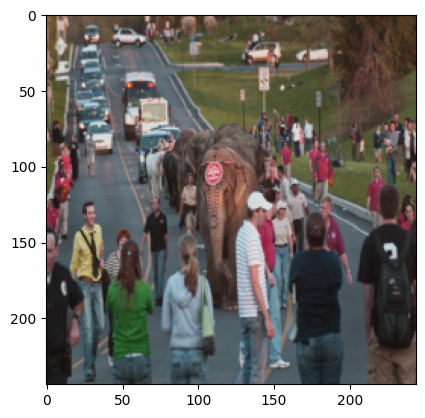

Label: tensor(3)


In [6]:
#test dataloader
train_images, train_labels = next(iter(training_data_loader))
print("Features batch shape: " + str(train_images.size()))
print("Labels batch shape: " + str(train_labels.size()))

img = train_images[0].squeeze()
label = train_labels[0]

img_to_plot = img.permute(1, 2, 0)
plt.imshow(img_to_plot)
plt.show()
print("Label: " + str(label))